# Treinamento do modelo

Notebook consome `data/model_dataset.parquet` (gerado por `preprocessamento-feature-engineering.ipynb`) e treina os três modelos supervisionados: **regressão logística**, **XGBoost** e **MLP**.

Cada célula abaixo é um passo do pipeline — só o *nome do que precisa ser feito*. Preencher com código depois.

In [2]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from xgboost import XGBClassifier

from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)

REPO = Path.cwd()
DATASET = REPO / 'data' / 'model_dataset.parquet'
ARTIFACTS = REPO / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)

df = pd.read_parquet(DATASET)
df['ano_mes'] = pd.PeriodIndex(df['ano_mes'], freq='M')
print(f'Linhas: {len(df):,}')
print(f'Colunas: {df.shape[1]}')
print(f'Período: {df["ano_mes"].min()} → {df["ano_mes"].max()}')
df.head()

Linhas: 385,560
Colunas: 18
Período: 2021-01 → 2025-12


,stop_id,ano_mes,lat,lon,num_rotas_servindo,pagerank,num_reclamacoes_3m,num_reclamacoes_6m,num_reclamacoes_12m,num_reclamacoes_seguranca_3m,num_reclamacoes_seguranca_6m,num_reclamacoes_seguranca_12m,num_reclamacoes_iluminacao_3m,num_reclamacoes_iluminacao_6m,num_reclamacoes_iluminacao_12m,mes,ano,y
0,1001O00010C1,2021-01,-22.897488,-43.186627,2,0.000086,0,1,2,0,1,1,0,0,0,1,2021,0
1,1001O00010C1,2021-02,-22.897488,-43.186627,2,0.000086,0,0,2,0,0,1,0,0,0,2,2021,0
2,1001O00010C1,2021-03,-22.897488,-43.186627,2,0.000086,0,0,1,0,0,1,0,0,0,3,2021,0
3,1001O00010C1,2021-04,-22.897488,-43.186627,2,0.000086,0,0,1,0,0,1,0,0,0,4,2021,0
4,1001O00010C1,2021-05,-22.897488,-43.186627,2,0.000086,0,0,1,0,0,1,0,0,0,5,2021,0


In [3]:
# Proporção de paradas com tiroteios próximos (< 500m)
df.groupby('ano_mes')['y'].mean()

ano_mes
2021-01    0.165733
2021-02    0.180828
2021-03    0.236072
2021-04    0.185185
2021-05    0.209928
2021-06    0.183162
2021-07    0.177404
2021-08    0.170713
2021-09    0.133209
2021-10    0.152661
2021-11    0.113290
2021-12    0.122160
2022-01    0.119048
2022-02    0.173514
2022-03    0.223934
2022-04    0.216931
2022-05    0.176626
2022-06    0.224556
2022-07    0.215064
2022-08    0.193900
2022-09    0.166978
2022-10    0.168223
2022-11    0.195767
2022-12    0.155307
2023-01    0.164955
2023-02    0.135232
2023-03    0.194678
2023-04    0.163710
2023-05    0.175537
2023-06    0.172891
2023-07    0.125428
2023-08    0.103641
2023-09    0.117803
2023-10    0.125117
2023-11    0.110800
2023-12    0.138655
2024-01    0.105820
2024-02    0.126206
2024-03    0.145814
2024-04    0.141145
2024-05    0.161843
2024-06    0.136632
2024-07    0.139122
2024-08    0.128073
2024-09    0.133987
2024-10    0.125428
2024-11    0.129163
2024-12    0.108777
2025-01    0.152039
2025-02    0

## Analise exploratoria (EDA)

Cinco visoes do dataset **antes do split**. Objetivo: entender a distribuicao do target, das features e a relacao entre elas.

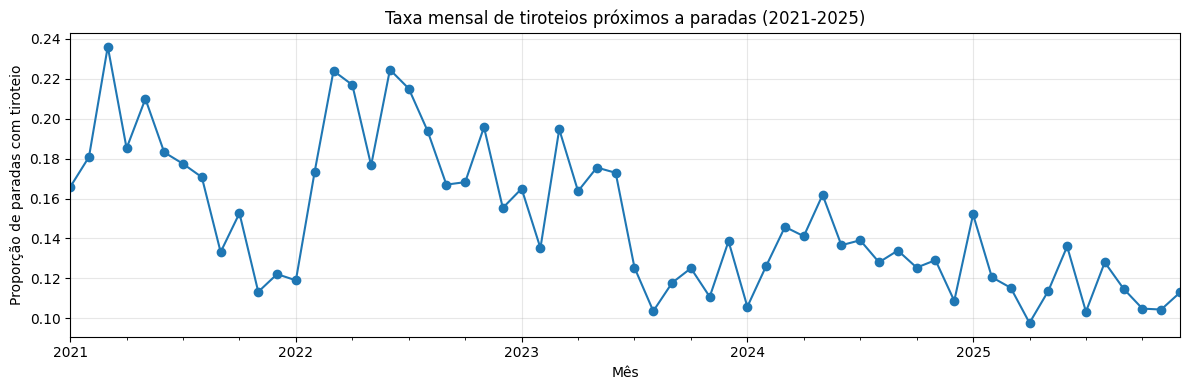

In [4]:
# EDA 1 - Distribuicao temporal do target
# taxa mensal de y ao longo dos 60 meses; olhar tendencia e outliers

taxa_por_mes = df.groupby('ano_mes')['y'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
taxa_por_mes.plot(ax=ax, marker='o')
ax.set_ylabel('Proporção de paradas com tiroteio')
ax.set_xlabel('Mês')
ax.set_title('Taxa mensal de tiroteios próximos a paradas (2021-2025)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

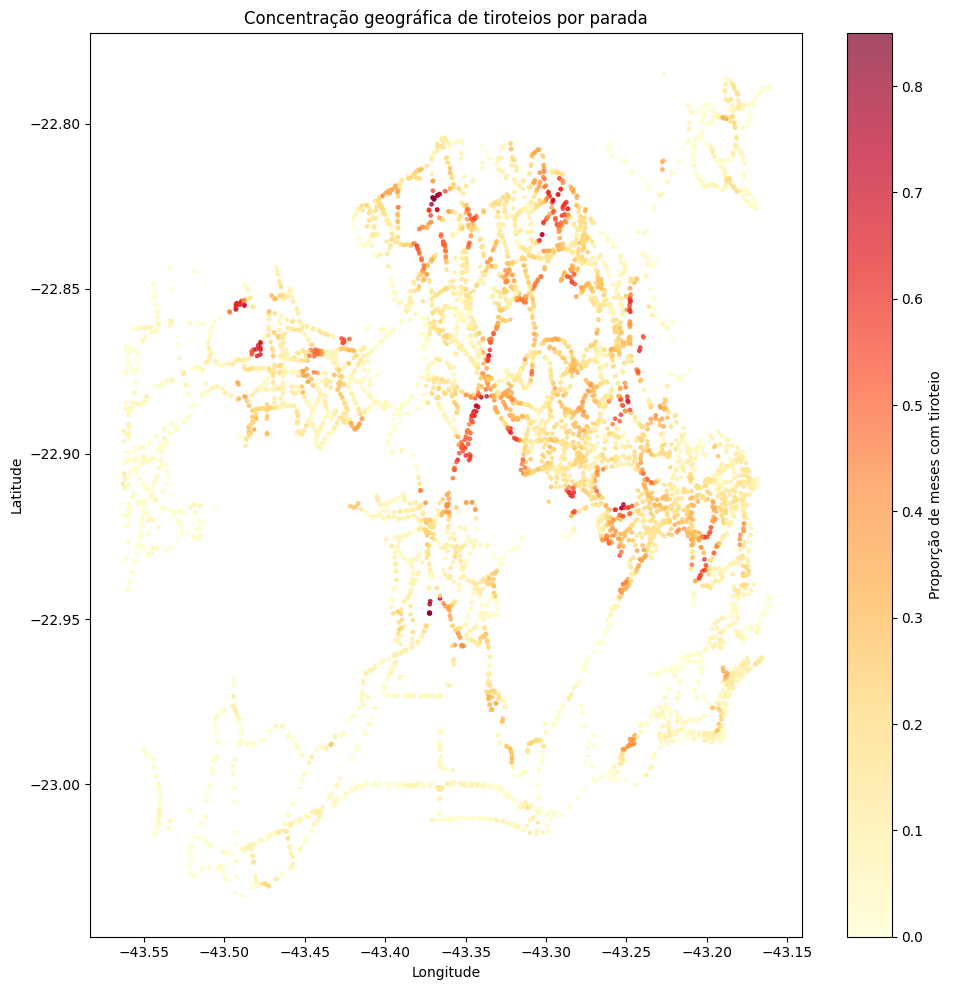

In [5]:
# EDA 2 - Distribuicao espacial do target
# scatter geografico das paradas colorido por proporcao de meses positivos
prop_por_parada = df.groupby('stop_id').agg(
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    prop_positivo=('y', 'mean'),
    n_meses=('y', 'count'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(
    prop_por_parada['lon'], prop_por_parada['lat'],
    c=prop_por_parada['prop_positivo'],
    cmap='YlOrRd', s=6, alpha=0.7,
)
plt.colorbar(sc, ax=ax, label='Proporção de meses com tiroteio')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Concentração geográfica de tiroteios por parada')
plt.tight_layout()
plt.show()

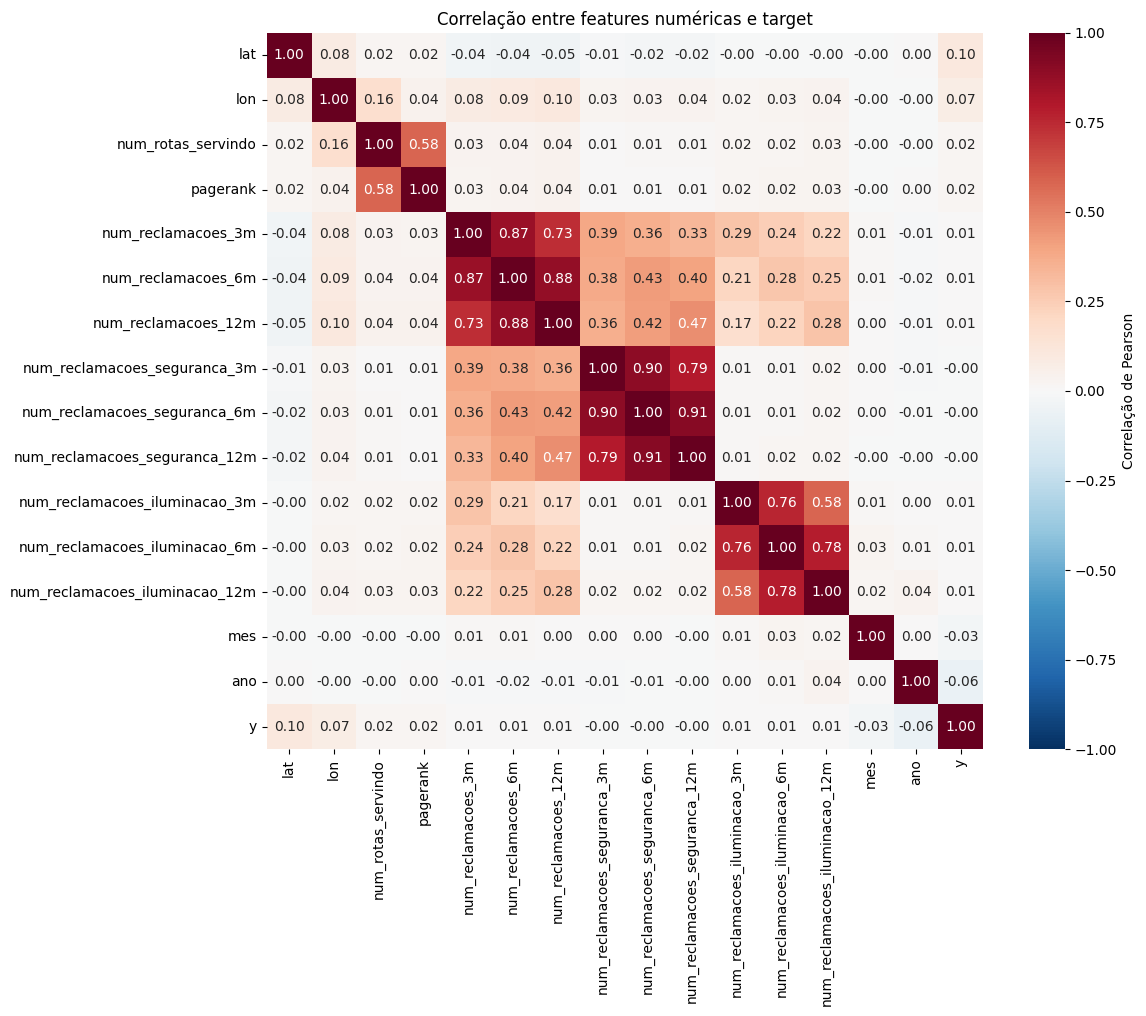

In [6]:
# EDA 3 - Matriz de correlacao (features + y)
# heatmap sobre features numericas + y; multicolinearidade e sinal com target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={'label': 'Correlação de Pearson'},
)
ax.set_title('Correlação entre features numéricas e target')
plt.tight_layout()
plt.show()

Reclamações do 1746, isoladamente, não predizem violência armada, pois a correlação linear é próxima de zero. Mas será que modelos não-lineares conseguem extrair sinal via interações entre reclamações, geografia e sazonalidade?

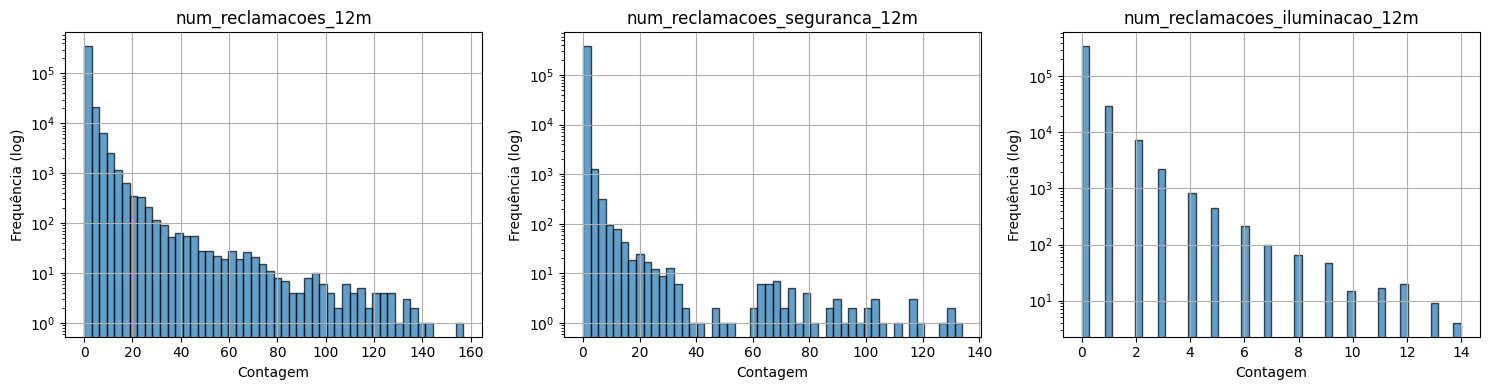

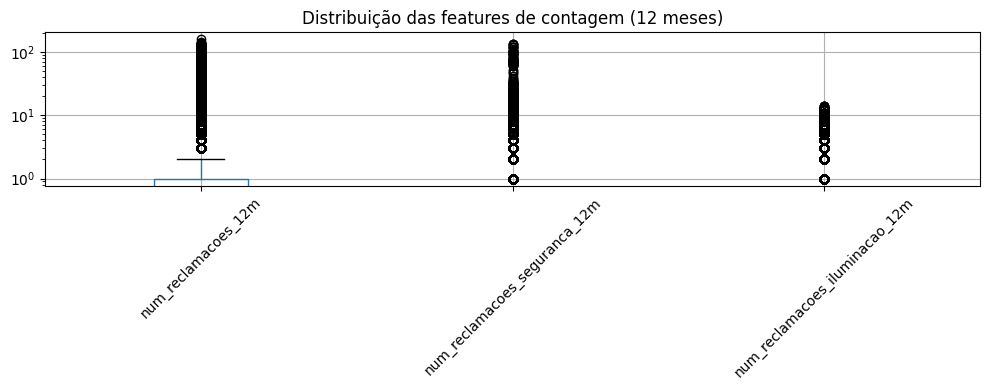

In [7]:
# EDA 4 - Distribuicao das features de reclamacao
# histogramas de num_reclamacoes_*_12m; conferir cauda longa que motiva log1p
count_cols = [c for c in df.columns if c.startswith('num_reclamacoes_') and c.endswith('_12m')]

fig, axes = plt.subplots(1, len(count_cols), figsize=(5 * len(count_cols), 4))
for ax, col in zip(axes, count_cols):
    df[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_yscale('log')  # log no eixo Y é essencial — sem isso só se vê o pico em 0
    ax.set_xlabel('Contagem')
    ax.set_ylabel('Frequência (log)')
plt.tight_layout()
plt.show()

# alternativa: box plot para ver quartis e outliers
fig, ax = plt.subplots(figsize=(10, 4))
df[count_cols].boxplot(ax=ax)
ax.set_yscale('log')  # mesma coisa
ax.set_title('Distribuição das features de contagem (12 meses)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A ideia de utilizar log é pelo fato do dataset ter muitos zeros nessas colunas, sem log o gráfico não funcionaria

Pela lógica vai ser necessário normalizar esses dados usando log1p, visto que sem a transformação o comportamento dessas features ficarão errados, o modelo vai aprender que 0-1 tem o mesmo peso que 120-121 reclamações e isso não é verdade.

# Transform

Ajustes que podem ser feitos no df inteiro antes do split

In [8]:
# codificação cíclica do mês: mes -> (mes_sin, mes_cos)
# faz jan (1) e dez (12) ficarem próximos no espaço de features (calendário é circular).

df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
df = df.drop(columns=['mes'])

In [9]:
# log1p nas features de contagem (num_reclamacoes_*)

features_reclamacoes = ['num_reclamacoes_3m',
 'num_reclamacoes_6m',
 'num_reclamacoes_12m',
 'num_reclamacoes_seguranca_3m',
 'num_reclamacoes_seguranca_6m',
 'num_reclamacoes_seguranca_12m',
 'num_reclamacoes_iluminacao_3m',
 'num_reclamacoes_iluminacao_6m',
 'num_reclamacoes_iluminacao_12m']

df[features_reclamacoes] = np.log1p(df[features_reclamacoes])

df



,stop_id,ano_mes,lat,lon,num_rotas_servindo,pagerank,num_reclamacoes_3m,num_reclamacoes_6m,num_reclamacoes_12m,num_reclamacoes_seguranca_3m,num_reclamacoes_seguranca_6m,num_reclamacoes_seguranca_12m,num_reclamacoes_iluminacao_3m,num_reclamacoes_iluminacao_6m,num_reclamacoes_iluminacao_12m,ano,y,mes_sin,mes_cos
0,1001O00010C1,2021-01,-22.897488,-43.186627,2,0.000086,0.0,0.693147,1.098612,0.0,0.693147,0.693147,0.0,0.0,0.0,2021,0,5.000000e-01,8.660254e-01
1,1001O00010C1,2021-02,-22.897488,-43.186627,2,0.000086,0.0,0.000000,1.098612,0.0,0.000000,0.693147,0.0,0.0,0.0,2021,0,8.660254e-01,5.000000e-01
2,1001O00010C1,2021-03,-22.897488,-43.186627,2,0.000086,0.0,0.000000,0.693147,0.0,0.000000,0.693147,0.0,0.0,0.0,2021,0,1.000000e+00,6.123234e-17
3,1001O00010C1,2021-04,-22.897488,-43.186627,2,0.000086,0.0,0.000000,0.693147,0.0,0.000000,0.693147,0.0,0.0,0.0,2021,0,8.660254e-01,-5.000000e-01
4,1001O00010C1,2021-05,-22.897488,-43.186627,2,0.000086,0.0,0.000000,0.693147,0.0,0.000000,0.693147,0.0,0.0,0.0,2021,0,5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385555,3105BC0001P2,2025-08,-22.839460,-43.239770,2,0.000028,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,2025,0,-8.660254e-01,-5.000000e-01
385556,3105BC0001P2,2025-09,-22.839460,-43.239770,2,0.000028,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,2025,0,-1.000000e+00,-1.836970e-16
385557,3105BC0001P2,2025-10,-22.839460,-43.239770,2,0.000028,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,2025,0,-8.660254e-01,5.000000e-01
385558,3105BC0001P2,2025-11,-22.839460,-43.239770,2,0.000028,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,2025,0,-5.000000e-01,8.660254e-01


# Divisão de treino/teste

In [10]:
# split temporal (treino / val / teste por ano_mes)
df_treino = df[df['ano_mes'] < '2024-01'].sort_values('ano_mes').reset_index(drop=True)
df_val    = df[(df['ano_mes'] >= '2024-01') & (df['ano_mes'] < '2025-01')].sort_values('ano_mes').reset_index(drop=True)
df_teste  = df[df['ano_mes'] >= '2025-01'].sort_values('ano_mes').reset_index(drop=True)

In [11]:
df_treino.groupby('ano_mes')['y'].mean()

ano_mes
2021-01    0.165733
2021-02    0.180828
2021-03    0.236072
2021-04    0.185185
2021-05    0.209928
2021-06    0.183162
2021-07    0.177404
2021-08    0.170713
2021-09    0.133209
2021-10    0.152661
2021-11    0.113290
2021-12    0.122160
2022-01    0.119048
2022-02    0.173514
2022-03    0.223934
2022-04    0.216931
2022-05    0.176626
2022-06    0.224556
2022-07    0.215064
2022-08    0.193900
2022-09    0.166978
2022-10    0.168223
2022-11    0.195767
2022-12    0.155307
2023-01    0.164955
2023-02    0.135232
2023-03    0.194678
2023-04    0.163710
2023-05    0.175537
2023-06    0.172891
2023-07    0.125428
2023-08    0.103641
2023-09    0.117803
2023-10    0.125117
2023-11    0.110800
2023-12    0.138655
Freq: M, Name: y, dtype: float64

In [12]:
# separar chaves (stop_id, ano_mes) e target (y) das features

X_train = df_treino.drop(columns=['stop_id', 'ano_mes', 'y'])
y_train = df_treino['y']

X_val = df_val.drop(columns=['stop_id', 'ano_mes', 'y'])
y_val = df_val['y']

X_test = df_teste.drop(columns=['stop_id', 'ano_mes', 'y'])
y_test = df_teste['y']

In [13]:
X_train.columns.tolist()

['lat',
 'lon',
 'num_rotas_servindo',
 'pagerank',
 'num_reclamacoes_3m',
 'num_reclamacoes_6m',
 'num_reclamacoes_12m',
 'num_reclamacoes_seguranca_3m',
 'num_reclamacoes_seguranca_6m',
 'num_reclamacoes_seguranca_12m',
 'num_reclamacoes_iluminacao_3m',
 'num_reclamacoes_iluminacao_6m',
 'num_reclamacoes_iluminacao_12m',
 'ano',
 'mes_sin',
 'mes_cos']

# Fit

Ajustes que precisam ser feitos separadamente entre treino e teste

In [14]:
# StandardScaler (fit no treino, transform em val e teste)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Regressão logística

In [15]:
# grid search da logística (C, penalty; usar TimeSeriesSplit para respeitar ordem temporal)

In [16]:
# treino da regressão logística (class_weight='balanced')

In [17]:
# avaliação da logística no val — AUC-ROC, matriz de confusão

In [18]:
# análise dos coeficientes da logística (quais features pesam mais e em que direção)

# XGBoost

In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 2. definir o grid como dict
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5,],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

gs_xgb = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42,
        tree_method='hist',   # ← adiciona pra acelerar
    ),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    refit=True,
)

gs_xgb.fit(X_train_scaled, y_train)

print('Melhores params:', gs_xgb.best_params_)
print('Melhor AUC (CV):', gs_xgb.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=   0.9s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.8; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.8; total time=   1.6s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=0.8; total time=   1.9s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=   2.0s

In [20]:
xgb_model = gs_xgb.best_estimator_

Melhores params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Melhor AUC (CV): 0.7233741053064509

In [21]:
# avaliação do XGBoost no val — AUC-ROC, Precision@100, matriz de confusão

y_pred_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]                          
y_pred_class_xgb = xgb_model.predict(X_val_scaled)

print(f'AUC-ROC no val: {roc_auc_score(y_val, y_pred_prob):.4f}')
print()
print('Matriz de confusão:')
print(confusion_matrix(y_val, y_pred_class_xgb))
print()
print('Classification report:')
print(classification_report(y_val, y_pred_class_xgb))


AUC-ROC no val: 0.7105

Matriz de confusão:
[[46598 20348]
 [ 4249  5917]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     66946
           1       0.23      0.58      0.32     10166

    accuracy                           0.68     77112
   macro avg       0.57      0.64      0.56     77112
weighted avg       0.83      0.68      0.73     77112



In [22]:
# 1. Confere que probabilidades TÊM variação (não são todas iguais)
y_pred_prob = xgb_model.predict_proba(X_val_scaled)[:, 1]  
print(f'min: {y_pred_prob.min():.4f}')
print(f'max: {y_pred_prob.max():.4f}')
print(f'mean: {y_pred_prob.mean():.4f}')
print(f'>0.5: {(y_pred_prob > 0.5).sum()}')

min: 0.0078
max: 0.8962
mean: 0.3895
>0.5: 26265


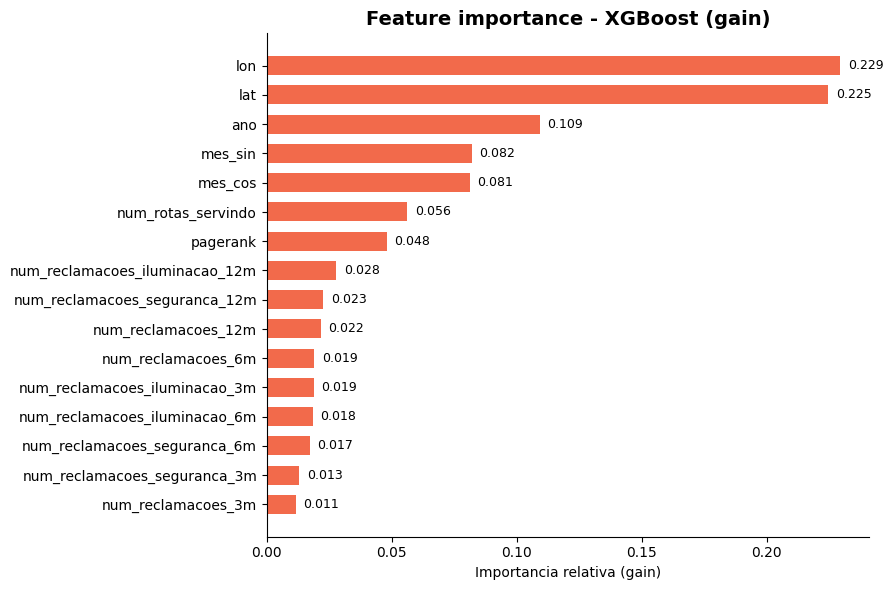

In [23]:
# 1. Feature importance (gain)

imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(imp['feature'], imp['importance'], color='#F26A4B', height=0.65)
ax.set_title('Feature importance - XGBoost (gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia relativa (gain)')
for bar, val in zip(bars, imp['importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

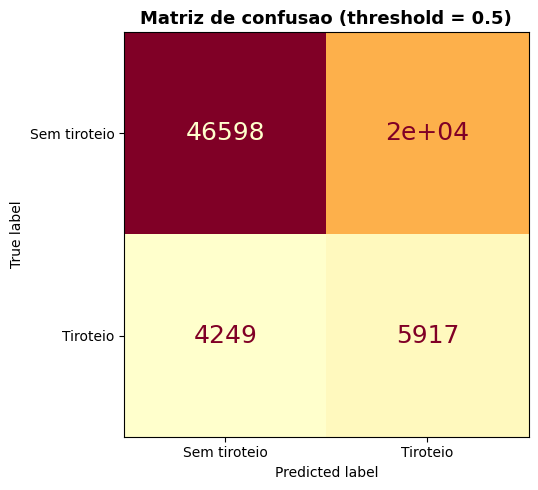

In [24]:
# 2. Matriz de confusao (threshold 0.5)

from sklearn.metrics import ConfusionMatrixDisplay

y_pred_class = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_class)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Sem tiroteio', 'Tiroteio']).plot(
    cmap='YlOrRd', ax=ax, colorbar=False,
    text_kw={'fontsize': 18}
)
ax.set_title('Matriz de confusao (threshold = 0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

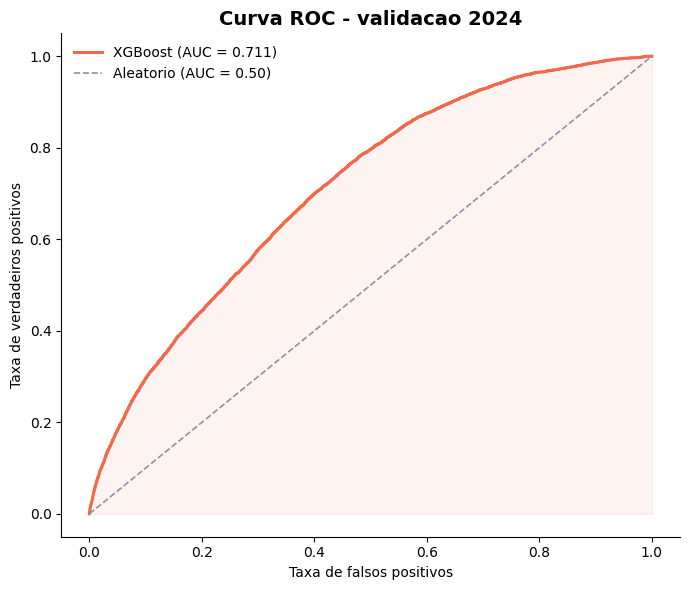

In [25]:
# 3. Curva ROC

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#F26A4B', lw=2.2, label=f'XGBoost (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='#8A93A3', lw=1.2, label='Aleatorio (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#F26A4B')
ax.set_xlabel('Taxa de falsos positivos')
ax.set_ylabel('Taxa de verdadeiros positivos')
ax.set_title('Curva ROC - validacao 2024', fontsize=14, fontweight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

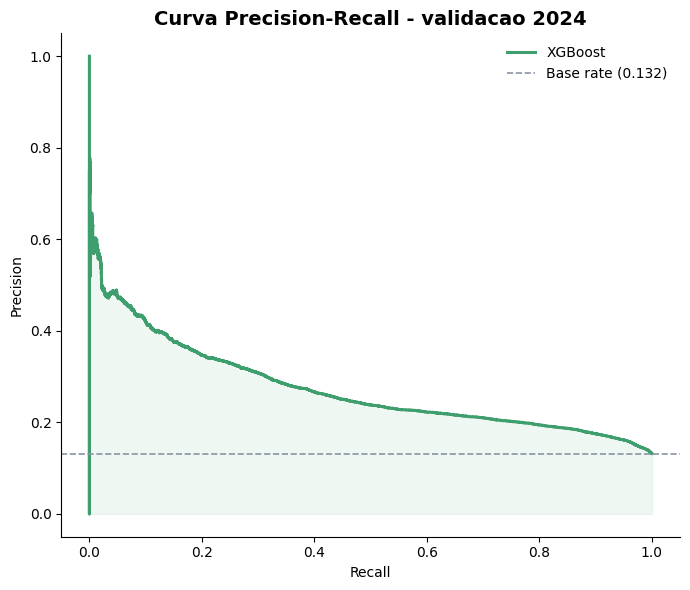

In [26]:
# 4. Curva Precision-Recall (mais adequada para dataset desbalanceado)

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, y_pred_prob)
base_rate = y_val.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.step(recall, precision, color='#3F9E6E', lw=2.2,
        where='post', label='XGBoost')
ax.axhline(y=base_rate, color='#8A93A3', ls='--', lw=1.2,
           label=f'Base rate ({base_rate:.3f})')
ax.fill_between(recall, precision, alpha=0.08,
                 color='#3F9E6E', step='post')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall - validacao 2024',
              fontsize=14, fontweight='bold')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

A curva começa alta (precision ≈ 0.9 com recall ≈ 0.05) — quando o modelo é muito conservador e só alerta as 5% paradas mais óbvias, ele acerta ~90%. Isso é o threshold alto (tipo 0.8+ de probabilidade).

Conforme você relaxa o threshold (vai descendo a curva para a direita), o recall sobe (pega mais tiroteios) mas a precision cai (mais alarmes falsos). No ponto em que o recall chega a ~0.8, a precision já caiu para ~0.25.

A curva sempre fica acima da linha tracejada — isso significa que, para qualquer nível de recall, seu modelo é melhor que aleatório. Não é óbvio: se as features fossem inúteis, a curva ficaria colada na linha cinza.

# MLP

In [27]:
# grid search do MLP (hidden_layer_sizes, alpha, learning_rate_init; TimeSeriesSplit)

In [28]:
# treino do MLP (sklearn MLPClassifier — 2 camadas ocultas, early stopping)

In [29]:
# avaliação do MLP no val — AUC-ROC, matriz de confusão

# Análise comparativa entre modelos

In [30]:
# tabela comparativa no val: baseline vs logística vs XGBoost vs MLP
# métricas: AUC-ROC, tempo de treino

In [31]:
# análise dos erros — em quais paradas / meses / bairros o modelo erra mais?
# onde os três modelos discordam entre si?

# Modelo final

In [32]:
# persistência: salvar scaler, modelo escolhido e predições no val em disco
# (para eventual página de predição interativa no Streamlit e para reproduzibilidade)

# --- 1. Scaler ---
# Sem ele, features novas não podem ser normalizadas na mesma escala do treino.
joblib.dump(scaler, ARTIFACTS / 'scaler.joblib')

# --- 2. Modelo XGBoost campeão ---
# Salvamos em dois formatos:
#  (a) .joblib — abre em qualquer script Python com sklearn/xgboost instalados.
#  (b) .json  — formato nativo do XGBoost, portável entre linguagens.
joblib.dump(xgb_model, ARTIFACTS / 'xgb_model.joblib')
xgb_model.save_model(ARTIFACTS / 'xgb_model.json')

# --- 3. Predições no val (para análise futura e comparação com outros modelos) ---
val_predictions = pd.DataFrame({
    'stop_id': df_val['stop_id'],
    'ano_mes': df_val['ano_mes'].astype(str),  # Period não serializa em parquet
    'y_true': y_val.values,
    'y_pred_prob_xgb': xgb_model.predict_proba(X_val_scaled)[:, 1],
    'y_pred_class_xgb': xgb_model.predict(X_val_scaled),
})
val_predictions.to_parquet(ARTIFACTS / 'val_predictions.parquet', index=False)

# --- 4. Metadados: features, hiperparâmetros, períodos ---
import json as _json

metadata = {
    'features': X_train.columns.tolist(),
    'best_params': xgb_model.get_params(),
    'scale_pos_weight': float(scale_pos_weight),
    'train_period': f'{df_treino["ano_mes"].min()} - {df_treino["ano_mes"].max()}',
    'val_period':   f'{df_val["ano_mes"].min()} - {df_val["ano_mes"].max()}',
    'test_period':  f'{df_teste["ano_mes"].min()} - {df_teste["ano_mes"].max()}',
}
with open(ARTIFACTS / 'metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2, default=str)

# --- 5. Confirmar o que foi salvo ---
print(f'Artefatos salvos em: {ARTIFACTS}\n')
for path in sorted(ARTIFACTS.iterdir()):
    size_kb = path.stat().st_size / 1024
    print(f'  {path.name:30s}  {size_kb:>10,.1f} KB')

Artefatos salvos em: /Users/vinicius.maciel/CascadeProjects/poli/riomobianalytics/artifacts

  metadata.json                          1.7 KB
  scaler.joblib                          1.5 KB
  val_predictions.parquet              621.8 KB
  xgb_model.joblib                     768.5 KB
  xgb_model.json                     1,116.6 KB
